## Hands-On Project: Sentiment Analysis using Logistic Regression

### Project Objective:
In this project, you will learn how to preprocess text data and build a **Logistic Regression model** to classify **IMDB movie reviews** as either positive or negative. The project involves:
- **Text cleaning**: Removing punctuation, converting text to lowercase.
- **Tokenization**: Breaking text into individual words.
- **Stop word removal**: Eliminating common words that do not contribute to sentiment.
- **TF-IDF Transformation**: Converting text data into numerical features using the Term Frequency-Inverse Document Frequency (TF-IDF) technique.
- **Classification**: Training a Logistic Regression model for sentiment classification.

---

## Step 1: Import Required Libraries
First, we need to import the necessary libraries for text preprocessing, feature extraction, and machine learning. These libraries will help us clean text, transform it into numerical values, and train a model.


In [2]:
import numpy as np
import pandas as pd
import nltk
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # This line downloads the punkt_tab data

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Step 2: Load and Explore the IMDB Dataset
We will load a dataset containing movie reviews and their corresponding sentiment (positive or negative). This dataset helps us understand how text data can be structured for machine learning.


In [5]:
import os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# Construct the full path to the CSV file within the downloaded directory
csv_file_path = os.path.join(path, 'IMDB Dataset.csv')
df = pd.read_csv(csv_file_path)

# Display first few rows
print(df.head())

# Check class distribution
print(df['sentiment'].value_counts())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


**Explanation:**
- The dataset consists of two columns: **review** (the text of the movie review) and **sentiment** (positive or negative label).
- Checking the class distribution helps us understand if the dataset is balanced or biased.

---

## Step 3: Text Preprocessing
Raw text data contains unwanted characters, capitalization, and common words that do not contribute to sentiment classification. We will:
- Convert all text to **lowercase** to maintain uniformity.
- Remove **punctuation** as it does not affect sentiment.
- **Tokenize** words (split sentences into individual words).
- Remove **stop words** (common words like "the," "a," "is," that do not add value to classification).


In [6]:
# Cell 4 - Text Preprocessing
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = word_tokenize(text)  # Tokenize words
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]  # Remove stop words
    return " ".join(filtered_tokens)

# Apply text cleaning
df['cleaned_review'] = df['review'].apply(clean_text)




**Explanation:**
- Lowercasing makes words like "Great" and "great" the same.
- Removing punctuation simplifies text structure.
- Tokenization breaks sentences into words for processing.
- Stop words are removed because they do not provide meaningful sentiment information.

---

## Step 4: Convert Text to Numerical Features using TF-IDF
Machine learning models require numerical input. The **TF-IDF (Term Frequency-Inverse Document Frequency)** technique helps convert text into meaningful numerical values by assigning importance to words based on their frequency and uniqueness.


In [7]:
# Cell 5 - Convert Text to Numerical Features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
# Ensure df['cleaned_review'] is available before using it
X = vectorizer.fit_transform(df['cleaned_review'])
y = df['sentiment'].map({'positive': 1, 'negative': 0})  # Convert labels to numerical format

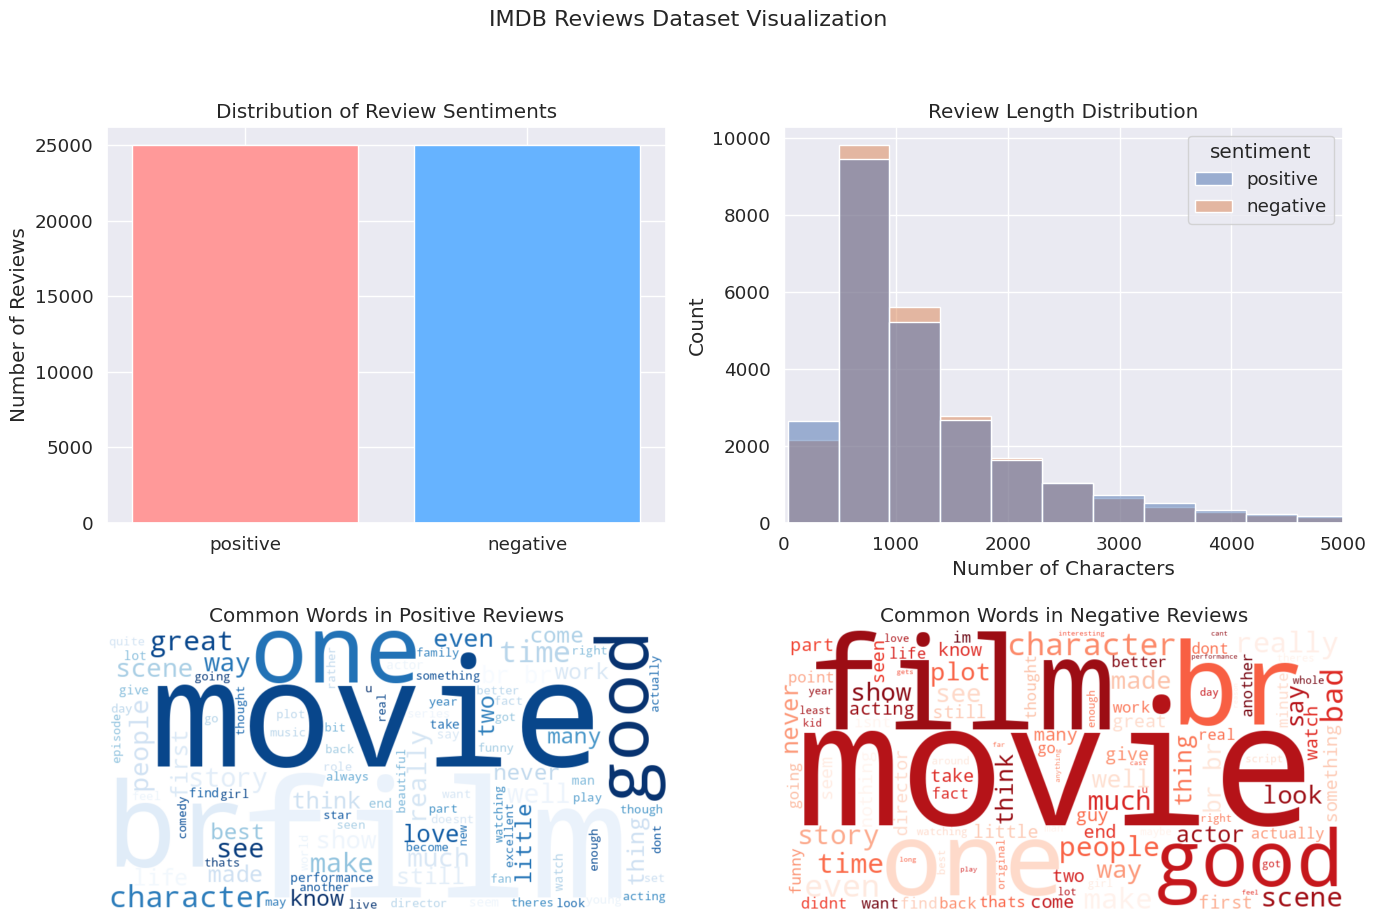

Average positive review length: 1324.8 characters
Average negative review length: 1294.1 characters

Most common words in positive reviews:
- br: 2304
- film: 1600
- movie: 1399
- one: 1067
- like: 702
- good: 553
- story: 511
- great: 485
- see: 461
- time: 445

Most common words in negative reviews:
- br: 2254
- movie: 1905
- film: 1262
- one: 952
- like: 814
- would: 564
- good: 553
- even: 548
- bad: 526
- really: 478


In [8]:
# Data Visualization - Understanding our Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import pandas as pd
import numpy as np

# Set style for better visualization
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('IMDB Reviews Dataset Visualization', fontsize=16)

# 1. Class Distribution (Top-left)
sentiment_counts = df['sentiment'].value_counts()
axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=['#ff9999', '#66b3ff'])
axes[0, 0].set_title('Distribution of Review Sentiments')
axes[0, 0].set_ylabel('Number of Reviews')

# 2. Review Length Distribution (Top-right)
df['review_length'] = df['review'].apply(len)
sns.histplot(data=df, x='review_length', hue='sentiment', bins=30, ax=axes[0, 1])
axes[0, 1].set_title('Review Length Distribution')
axes[0, 1].set_xlabel('Number of Characters')
axes[0, 1].set_xlim(0, 5000)  # Focus on the main range

# 3. Word Clouds (Bottom row)
# For Positive Reviews
positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'].sample(1000))
wordcloud_positive = WordCloud(width=800, height=400, background_color='white',
                              colormap='Blues', max_words=100).generate(positive_text)
axes[1, 0].imshow(wordcloud_positive, interpolation='bilinear')
axes[1, 0].set_title('Common Words in Positive Reviews')
axes[1, 0].axis('off')

# For Negative Reviews
negative_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'].sample(1000))
wordcloud_negative = WordCloud(width=800, height=400, background_color='white',
                              colormap='Reds', max_words=100).generate(negative_text)
axes[1, 1].imshow(wordcloud_negative, interpolation='bilinear')
axes[1, 1].set_title('Common Words in Negative Reviews')
axes[1, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print some statistics about the reviews
print(f"Average positive review length: {df[df['sentiment'] == 'positive']['review_length'].mean():.1f} characters")
print(f"Average negative review length: {df[df['sentiment'] == 'negative']['review_length'].mean():.1f} characters")
print("\nMost common words in positive reviews:")
pos_words = Counter(" ".join(df[df['sentiment'] == 'positive']['cleaned_review'].sample(1000)).split()).most_common(10)
for word, count in pos_words:
    print(f"- {word}: {count}")

print("\nMost common words in negative reviews:")
neg_words = Counter(" ".join(df[df['sentiment'] == 'negative']['cleaned_review'].sample(1000)).split()).most_common(10)
for word, count in neg_words:
    print(f"- {word}: {count}")

**Explanation:**
- **TF-IDF** captures word importance while reducing emphasis on overly frequent words.
- **max_features=5000** ensures we only keep the 5000 most important words.
- We **map labels to 1 and 0** for easier classification.

---

## Step 5: Split Data into Training and Testing Sets
Before training, we must split our dataset into training and testing sets to evaluate model performance fairly.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Explanation:**
- **80%** of the data is used for training.
- **20%** is held out for testing.
- **random_state=42** ensures reproducibility of results.

---

## Step 6: Train a Logistic Regression Model
Logistic Regression is a simple yet effective classification algorithm used widely in NLP tasks.

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**Explanation:**
- Logistic Regression predicts the probability of a review being positive or negative.
- It learns from training data and adjusts weights to minimize classification errors.

---

## Step 7: Evaluate the Model
After training, we assess how well the model performs on unseen test data.

In [12]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))

Accuracy: 88.84%
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



**Explanation:**
- **Accuracy**: Measures the percentage of correct predictions.
- **Classification Report**: Provides precision, recall, and F1-score metrics for deeper analysis.

---

## Conclusion:
- **Text preprocessing** is essential for improving model performance.
- **TF-IDF** helps transform text into a structured format suitable for machine learning.
- **Logistic Regression** is a good starting point for sentiment classification.
- **Model evaluation** helps measure effectiveness and guides improvements.

This project introduces key NLP techniques and helps in understanding sentiment classification with real-world data. 🚀